In [1]:
import os
import sys

import warnings
warnings.filterwarnings('ignore')

project_root = 'c:/big20/git/big20-ML-project2-team3/SantanderCS'
# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic'

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score
from utils.preprocessing import load_data, split_features_target, scale_data, data_split, remove_zero_columns2
from utils.user_utils import get_model_train_eval
from utils.feature_engineering import add_statistical_features,drop_highly_correlated_features

In [3]:
# 데이터 로딩 및 기본 전처리
train, test = load_data()
X_features, y_labels = split_features_target(train)
X_test = test.drop(columns=['ID'], axis=1)

In [4]:
# zero_count_rate 제거
X_features, X_test = remove_zero_columns2(X_features, X_test, 0.99)

# var3 처리
X_features['var3'] =  X_features['var3'].replace(-999999, 2)


Train Data Analysis (Threshold: 99.0% )
Train rows: 76,020, columns: 369
Test rows: 75,818, columns: 369

                                   Train Summary (zero_count 내림차순)                                    
                   ColumnName  na_Sum  nUnique          mode  modeFreq modeFreqRate  zero_count zero_count_rate_display
saldo_medio_var13_medio_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
                     ind_var2       0        1      0.000000     76020      100.00%       76020                 100.00%
        num_reemb_var33_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
    num_trasp_var17_out_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
    num_trasp_var33_out_hace3       0        1      0.000000     76020      100.00%       76020                 100.00%
              saldo_var2_ult1       0        1      0.000000     76020

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, recall_score
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# 1. 기본 피처 처리 + 통계 피처 생성
X_features, X_test = remove_zero_columns2(X_features, X_test, 0.99)
X_features['var3'] = X_features['var3'].replace(-999999, 2)

X_features = add_statistical_features(X_features)
X_test = add_statistical_features(X_test)

# 2. threshold 리스트
thresholds = [0.85, 0.90, 0.95]

results = []
drop_columns = {}

# 3. HyperOpt 최적 하이퍼파라미터 기반 모델 정의
xgb_clf = XGBClassifier(
    colsample_bytree=0.6189145847340869,
    gamma=2.1975446881879566,
    learning_rate=0.014458073132414333,
    max_depth=7,
    min_child_weight=6,
    n_estimators=400,
    subsample=0.8352914228773503,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

log_clf = LogisticRegression(
    C=0.02872898758249208,
    class_weight=None,   # class_weight=1은 None과 동일
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

# 4. threshold별 반복
for th in thresholds:
    # 상관계수 기반 컬럼 제거
    X_reduced, to_drop = drop_highly_correlated_features(X_features, threshold=th)
    drop_columns[th] = to_drop
    X_test_reduced = X_test.drop(columns=to_drop)

    # 학습/검증 데이터 분리
    X_train, X_val, y_train, y_val = train_test_split(
        X_reduced, y_labels, test_size=0.2, random_state=42, stratify=y_labels
    )

    # -------------------
    # (1) XGBoost 평가
    # -------------------
    model_name = f'XGBoost_99per_hyperopt_th_fe{th}'
    get_model_train_eval(xgb_clf, model_name, X_train, X_val, y_train, y_val)

    y_pred = xgb_clf.predict(X_val)
    y_proba = xgb_clf.predict_proba(X_val)[:,1]

    results.append({
        'model': model_name,
        'threshold': th,
        'dropped_features': len(to_drop),
        'AUC': roc_auc_score(y_val, y_proba),
        'F1': f1_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred)
    })

    # -------------------
    # (2) Logistic Regression 평가
    # -------------------
    model_name = f'LogisticRegression_99per_hyperopt_th_fe{th}'
    get_model_train_eval(log_clf, model_name, X_train, X_val, y_train, y_val)

    y_pred = log_clf.predict(X_val)
    y_proba = log_clf.predict_proba(X_val)[:,1]

    results.append({
        'model': model_name,
        'threshold': th,
        'dropped_features': len(to_drop),
        'AUC': roc_auc_score(y_val, y_proba),
        'F1': f1_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred)
    })

# 결과 DataFrame으로 정리
results_df = pd.DataFrame(results)
print(results_df)


Train Data Analysis (Threshold: 99.0% )
Train rows: 76,020, columns: 156
Test rows: 75,818, columns: 156

                                   Train Summary (zero_count 내림차순)                                    
                   ColumnName  na_Sum  nUnique          mode  modeFreq modeFreqRate  zero_count zero_count_rate_display
            ind_var13_largo_0       0        2      0.000000     75247       98.98%       75247                  98.98%
            num_var13_largo_0       0        7      0.000000     75247       98.98%       75247                  98.98%
                  ind_var40_0       0        2      0.000000     75152       98.86%       75152                  98.86%
                  num_var40_0       0        3      0.000000     75152       98.86%       75152                  98.86%
                        var21       0       24      0.000000     75152       98.86%       75152                  98.86%
                   ind_var1_0       0        2      0.000000     75149

In [8]:
# threshold별 삭제된 컬럼 집합 (drop_columns dict에서 가져오기)
set_085 = set(drop_columns[0.85])
set_090 = set(drop_columns[0.90])
set_095 = set(drop_columns[0.95])

# 고유하게 삭제된 컬럼
unique_085 = set_085 - set_090 - set_095
unique_090 = set_090 - set_085 - set_095
unique_095 = set_095 - set_085 - set_090

print("0.85에서만 삭제된:", unique_085)
print("0.90에서만 삭제된:", unique_090)
print("0.95에서만 삭제된:", unique_095)

# 공통 삭제된 컬럼
common_all = set_085 & set_090 & set_095
print("모든 threshold에서 공통 삭제된:", common_all)

# unique/공통 컬럼 비교용 DataFrame
tmpdf = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in drop_columns.items()]))
tmpdf.to_csv("../data/99per_drop_columns.xls", index=False)


0.85에서만 삭제된: {'imp_op_var41_ult1', 'imp_op_var39_comer_ult3', 'saldo_medio_var13_corto_hace2', 'ind_var24_0', 'ind_var10_ult1', 'num_var42', 'num_var45_ult1', 'num_var26_0', 'ind_var8_0', 'num_var12_0', 'saldo_var13', 'num_var30', 'num_var39_0', 'saldo_medio_var12_hace2'}
0.90에서만 삭제된: set()
0.95에서만 삭제된: set()
모든 threshold에서 공통 삭제된: {'saldo_medio_var12_ult3', 'num_var13_corto_0', 'num_var8_0', 'num_var13_0', 'num_op_var39_ult1', 'ind_var40_0', 'num_var37', 'sum', 'ind_var13', 'ind_var25_0', 'ind_var41_0', 'delta_num_aport_var13_1y3', 'num_meses_var12_ult3', 'num_op_var39_ult3', 'mean', 'std', 'saldo_medio_var13_corto_ult3', 'imp_op_var39_efect_ult3', 'num_op_var41_comer_ult3', 'saldo_var24', 'ind_var26_cte', 'num_var8', 'num_meses_var13_corto_ult3', 'saldo_medio_var13_corto_ult1', 'num_var25_0', 'saldo_var42', 'ind_var25', 'num_var40_0', 'ind_var26', 'num_var25', 'num_var5', 'imp_op_var39_ult1', 'num_var45_ult3', 'ind_var13_corto', 'ind_var37', 'num_var12', 'num_op_var39_efect_ult3', 's

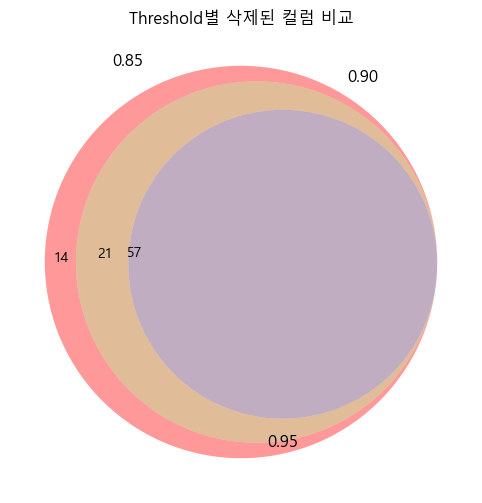

In [10]:
# Venn Diagram 그리기
# pip install matplotlib_venn
from matplotlib_venn import venn3

plt.figure(figsize=(8,6))
venn3([set_085, set_090, set_095], set_labels=('0.85','0.90','0.95'))
plt.title('Threshold별 삭제된 컬럼 비교')
plt.show()

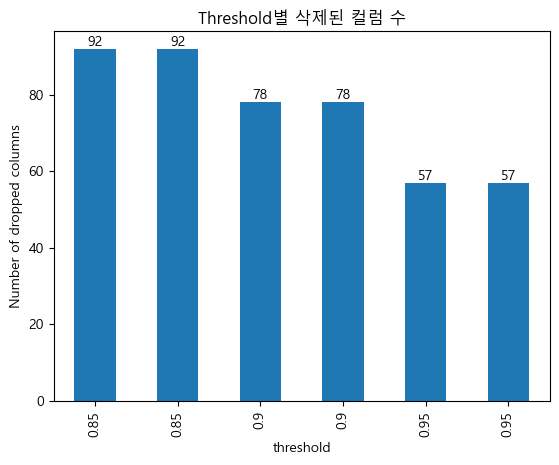

In [14]:
import matplotlib.pyplot as plt

ax = results_df.plot(
    x="threshold", 
    y="dropped_features", 
    kind="bar", 
    legend=False
)

plt.title("Threshold별 삭제된 컬럼 수")
plt.ylabel("Number of dropped columns")

# 막대 위에 수치 레이블 추가
ax.bar_label(ax.containers[0])

plt.show()


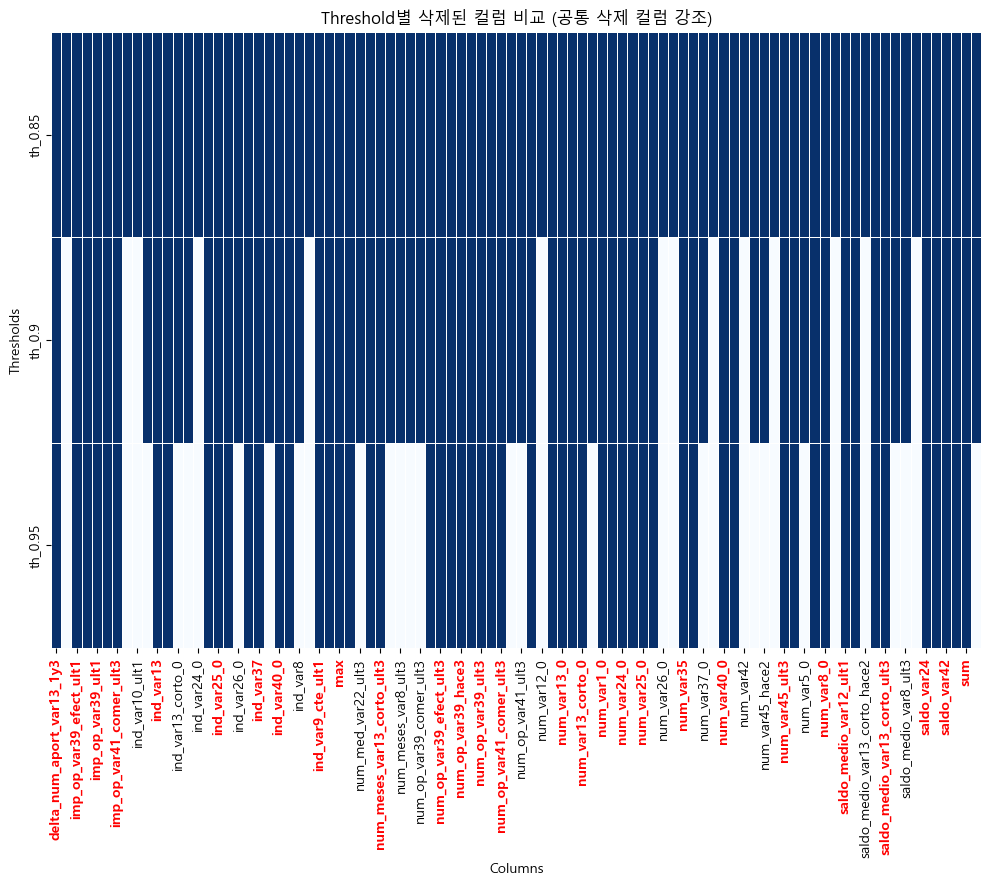

In [12]:
# 존재 여부 매트릭스 생성 (앞에서 만든 comparison_matrix)
# drop_columns 딕셔너리 안에 있는 모든 컬럼을 합쳐서 집합 생성
all_dropped = set()
for cols in drop_columns.values():
    all_dropped.update(cols)
    
comparison_matrix = pd.DataFrame(index=sorted(all_dropped))
for th, cols in drop_columns.items():
    comparison_matrix[f"th_{th}"] = comparison_matrix.index.isin(cols)
comparison_matrix = comparison_matrix.astype(int)

# 공통으로 삭제된 컬럼
common_all = set(drop_columns[0.85]) & set(drop_columns[0.90]) & set(drop_columns[0.95])

# heatmap 그리기
plt.figure(figsize=(12,8))
ax = sns.heatmap(comparison_matrix.T, cmap="Blues", cbar=False, linewidths=0.5)

# 공통 삭제된 컬럼에 대해 x축 라벨 색상 변경
for label in ax.get_xticklabels():
    if label.get_text() in common_all:
        label.set_color("red")   # 공통 삭제된 컬럼은 빨간색
        label.set_fontweight("bold")

plt.title("Threshold별 삭제된 컬럼 비교 (공통 삭제 컬럼 강조)")
plt.xlabel("Columns")
plt.ylabel("Thresholds")
plt.show()